# Proyek Pengembangan dan Pengoperasian Sistem Machine Learning

**Nama:** Jalu Prayoga  
**Dicoding Username:** jaluprayoga  
**Dataset:** Pima Indians Diabetes Dataset  

---

### Dataset Overview
The dataset used is the **Pima Indians Diabetes Dataset** downloaded from the [official GitHub repository (jbrownlee/Datasets)](https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv).

**Data Size:** 768 patient medical records (females aged >= 21 years).

**Number of Features:** 9 columns (8 numerical predictor features + 1 binary target):
1. `Pregnancies`: Number of pregnancies
2. `Glucose`: 2-hour oral glucose tolerance test plasma glucose concentration
3. `BloodPressure`: Diastolic blood pressure (mm Hg)
4. `SkinThickness`: Triceps skin fold thickness (mm)
5. `Insulin`: 2-hour serum insulin (mu U/ml)
6. `BMI`: Body mass index (weight in kg / (height in m)2)
7. `DiabetesPedigreeFunction`: Diabetes pedigree function score
8. `Age`: Patient age (years)
9. `Outcome` *(Target/Label)*: Diabetes status (`0` = Non-Diabetic, `1` = Diabetic)


### Problem Statement
Diabetes is a chronic metabolic disease with serious health risks whose clinical intervention is often delayed because symptoms are frequently asymptomatic in early stages. Automated and accurate early detection through routine physical and laboratory diagnostic measurements is vital to prevent fatal complications.

### Machine Learning Solution
Developing an End-to-End Machine Learning pipeline orchestrated using **Apache Beam (`BeamDagRunner`)** based on **TensorFlow Extended (TFX)**. The solution integrates **TensorFlow Transform (TFT)** for feature standardization, **KerasTuner** for automated hyperparameter optimization, a **Deep Neural Network (Multi-Layer Perceptron / MLP)** architecture, automated evaluation validation gates via **TensorFlow Model Analysis (TFMA)**, containerized model serving (**TensorFlow Serving / TF Serving**), and real-time observability (**Prometheus & Grafana**).


## 1. Environment & Pipeline Paths Initialization


In [1]:
import os
import sys
import logging
import warnings
import glob
import json
import base64
import requests
from absl import logging as absl_logging
from IPython.display import Image, display
import pandas as pd


import tensorflow as tf
import tensorflow_model_analysis as tfma
import tfx
import keras_tuner as kt

from modules.trainer import model_builder
from modules.pipeline import init_pipeline
from tfx.components import CsvExampleGen, StatisticsGen, SchemaGen, ExampleValidator, Transform, Tuner, Trainer, Evaluator, Pusher
from tfx.proto import example_gen_pb2, trainer_pb2, pusher_pb2

from tfx.dsl.components.common.resolver import Resolver
from tfx.dsl.input_resolution.strategies.latest_blessed_model_strategy import LatestBlessedModelStrategy
from tfx.orchestration.beam.beam_dag_runner import BeamDagRunner
from tfx.types import Channel
from tfx.types.standard_artifacts import Model, ModelBlessing




D:\Projects\Dicoding\Machine Learning Operations (MLOps)\Proyek Pengembangan dan Pengoperasian Sistem Machine Learning\venv\lib\site-packages\google\api_core\_python_version_support.py:254: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Could not find a compatible bson package.


In [2]:
# Suppress warning logs
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel(logging.ERROR)
absl_logging.set_verbosity(absl_logging.ERROR)

PIPELINE_NAME = "jaluprayoga-pipeline"
DATA_ROOT = "data"
MODULES_ROOT = "modules"
PIPELINE_ROOT = PIPELINE_NAME
METADATA_PATH = os.path.join(PIPELINE_ROOT, "metadata.sqlite")
SERVING_MODEL_DIR = "serving_model"

print(f"TFX Version: {tfx.__version__}")
print(f"Pipeline Name: {PIPELINE_NAME}")
print(f"Pipeline Root: {PIPELINE_ROOT}")
print(f"Metadata Path: {METADATA_PATH}")


TFX Version: 1.14.0
Pipeline Name: jaluprayoga-pipeline
Pipeline Root: jaluprayoga-pipeline
Metadata Path: jaluprayoga-pipeline\metadata.sqlite


## 2. ExampleGen (`CsvExampleGen`)
Import the CSV dataset from `data/diabetes.csv` and partition the data into 80% train and 20% eval splits using a hash-bucket-based split configuration.


In [3]:
output_config = example_gen_pb2.Output(
    split_config=example_gen_pb2.SplitConfig(
        splits=[
            example_gen_pb2.SplitConfig.Split(name="train", hash_buckets=8),
            example_gen_pb2.SplitConfig.Split(name="eval", hash_buckets=2),
        ]
    )
)
example_gen = CsvExampleGen(input_base=DATA_ROOT, output_config=output_config)


## 3. StatisticsGen
Compute summary statistics for training and evaluation splits.


In [4]:
statistics_gen = StatisticsGen(examples=example_gen.outputs["examples"])

## 4. SchemaGen
Automatically infer feature schema and data types based on computed statistics.


In [5]:
schema_gen = SchemaGen(
    statistics=statistics_gen.outputs["statistics"],
    infer_feature_shape=True,
)


## 5. ExampleValidator
Inspect anomalies or schema deviations across the dataset.


In [6]:
example_validator = ExampleValidator(
    statistics=statistics_gen.outputs["statistics"],
    schema=schema_gen.outputs["schema"],
)


## 6. Transform
Execute data preprocessing using TensorFlow Transform (`modules/transform.py`) with Z-score scaling.


In [7]:
transform = Transform(
    examples=example_gen.outputs["examples"],
    schema=schema_gen.outputs["schema"],
    module_file=os.path.abspath(os.path.join(MODULES_ROOT, "transform.py")),
)


## 7. Tuner
Perform automated hyperparameter tuning using KerasTuner (`modules/tuner.py`) with `val_recall` objective to prioritize diabetic sensitivity and minimize false negatives.

In [8]:
tuner = Tuner(
    module_file=os.path.abspath(os.path.join(MODULES_ROOT, "tuner.py")),
    examples=transform.outputs["transformed_examples"],
    transform_graph=transform.outputs["transform_graph"],
    schema=schema_gen.outputs["schema"],
    train_args=trainer_pb2.TrainArgs(splits=["train"], num_steps=20),
    eval_args=trainer_pb2.EvalArgs(splits=["eval"], num_steps=5),
)



## 8. Trainer
Train the Deep Neural Network (MLP) architecture using the optimal hyperparameters selected by the Tuner (`modules/trainer.py`).


In [9]:
trainer = Trainer(
    module_file=os.path.abspath(os.path.join(MODULES_ROOT, "trainer.py")),
    examples=transform.outputs["transformed_examples"],
    transform_graph=transform.outputs["transform_graph"],
    schema=schema_gen.outputs["schema"],
    hyperparameters=tuner.outputs["best_hyperparameters"],
    train_args=trainer_pb2.TrainArgs(splits=["train"], num_steps=20),
    eval_args=trainer_pb2.EvalArgs(splits=["eval"], num_steps=5),
)

## 9. Resolver (`LatestBlessedModelResolver`)
Retrieve the latest blessed baseline model from ML Metadata to facilitate performance comparison during evaluation.


In [10]:
model_resolver = Resolver(
    strategy_class=LatestBlessedModelStrategy,
    model=Channel(type=Model),
    model_blessing=Channel(type=ModelBlessing),
).with_id("latest_blessed_model_resolver")

## 10. Evaluator
Evaluation Metrics using **TensorFlow Model Analysis (TFMA)** in the `Evaluator` component:
1. **BinaryAccuracy**: Minimum threshold `value_threshold >= 0.60` (60%) and outperforming baseline (`change_threshold >= -0.1`).
2. **Recall**: Mandatory threshold `value_threshold >= 0.70` (70%) and better than baseline for model blessing.
3. **AUC (Area Under ROC Curve)**: Measures classification discriminative ability.
4. **Precision**: Measures accuracy of positive diabetic predictions.
5. **BinaryCrossentropy**: Assesses probabilistic loss divergence.


In [11]:
eval_config = tfma.EvalConfig(
    model_specs=[tfma.ModelSpec(label_key="Outcome")],
    slicing_specs=[tfma.SlicingSpec()],
    metrics_specs=[
        tfma.MetricsSpec(
            metrics=[
                tfma.MetricConfig(class_name="ExampleCount"),
                tfma.MetricConfig(
                    class_name="BinaryAccuracy",
                    threshold=tfma.MetricThreshold(
                        value_threshold=tfma.GenericValueThreshold(
                            lower_bound={"value": 0.60}
                        ),
                        change_threshold=tfma.GenericChangeThreshold(
                            direction=tfma.MetricDirection.HIGHER_IS_BETTER,
                            absolute={"value": -0.1},
                        ),
                    ),
                ),
                tfma.MetricConfig(
                    class_name="Recall",
                    threshold=tfma.MetricThreshold(
                        value_threshold=tfma.GenericValueThreshold(
                            lower_bound={"value": 0.70}
                        ),
                        change_threshold=tfma.GenericChangeThreshold(
                            direction=tfma.MetricDirection.HIGHER_IS_BETTER,
                            absolute={"value": -0.1},
                        ),
                    ),
                ),
                tfma.MetricConfig(class_name="AUC"),
                tfma.MetricConfig(class_name="Precision"),
                tfma.MetricConfig(class_name="BinaryCrossentropy"),
            ]
        )
    ],
)

evaluator = Evaluator(
    examples=example_gen.outputs["examples"],
    model=trainer.outputs["model"],
    baseline_model=model_resolver.outputs["model"],
    eval_config=eval_config,
)


## 11. Pusher
Export the model that achieved **BLESSED** status to the `serving_model/` directory.


In [12]:
pusher = Pusher(
    model=trainer.outputs["model"],
    model_blessing=evaluator.outputs["blessing"],
    push_destination=pusher_pb2.PushDestination(
        filesystem=pusher_pb2.PushDestination.Filesystem(
            base_directory=SERVING_MODEL_DIR
        )
    ),
)


## 12. Pipeline Orchestration & Execution with Apache Beam (`BeamDagRunner`)

Assemble all configured TFX components into an end-to-end pipeline using `init_pipeline()` from `modules/pipeline.py` and orchestrate the full execution workflow via Apache Beam's `BeamDagRunner`.


In [13]:
# Assemble all components into the pipeline
components = [
    example_gen,
    statistics_gen,
    schema_gen,
    example_validator,
    transform,
    tuner,
    trainer,
    model_resolver,
    evaluator,
    pusher,
]

# Initialize pipeline with Apache Beam DAG runner configuration
beam_pipeline = init_pipeline(
    pipeline_name=PIPELINE_NAME,
    pipeline_root=PIPELINE_ROOT,
    metadata_path=METADATA_PATH,
    components=components,
)

# Execute pipeline end-to-end
BeamDagRunner().run(pipeline=beam_pipeline)


Trial 10 Complete [00h 00m 02s]
val_recall: 0.7843137383460999

Best val_recall So Far: 0.9038461446762085
Total elapsed time: 00h 00m 24s
Results summary
Results in jaluprayoga-pipeline\Tuner\.system\executor_execution\7\.temp\7\diabetes_tuning
Showing 10 best trials
Objective(name="val_recall", direction="max")

Trial 01 summary
Hyperparameters:
units_1: 32
units_2: 40
learning_rate: 0.001
Score: 0.9038461446762085

Trial 04 summary
Hyperparameters:
units_1: 48
units_2: 8
learning_rate: 0.001
Score: 0.8799999952316284

Trial 08 summary
Hyperparameters:
units_1: 64
units_2: 48
learning_rate: 0.001
Score: 0.8627451062202454

Trial 00 summary
Hyperparameters:
units_1: 32
units_2: 64
learning_rate: 0.01
Score: 0.8461538553237915

Trial 07 summary
Hyperparameters:
units_1: 128
units_2: 64
learning_rate: 0.001
Score: 0.8461538553237915

Trial 06 summary
Hyperparameters:
units_1: 96
units_2: 64
learning_rate: 0.01
Score: 0.807692289352417

Trial 09 summary
Hyperparameters:
units_1: 16
units


[TRAINER] MODEL ARCHITECTURE & TRAINING CONFIGURATION
Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 Pregnancies_xf (InputLayer  [(None, 1)]                  0         []                            
 )                                                                                                
                                                                                                  
 Glucose_xf (InputLayer)     [(None, 1)]                  0         []                            
                                                                                                  
 BloodPressure_xf (InputLay  [(None, 1)]                  0         []                            
 er)                                                                                              
                                     

 1/20 [>.............................] - ETA: 19s - loss: 1.2420 - accuracy: 0.4688 - auc: 0.4706 - precision: 0.4286 - recall: 0.4000

20/20 [==============================] - 1s 22ms/step - loss: 1.0112 - accuracy: 0.5766 - auc: 0.6324 - precision: 0.4373 - recall: 0.6579 - val_loss: 0.6938 - val_accuracy: 0.6125 - val_auc: 0.7470 - val_precision: 0.4466 - val_recall: 0.9020


Epoch 2/20


...

 1/20 [>.............................] - ETA: 0s - loss: 0.7291 - accuracy: 0.8438 - auc: 0.8941 - precision: 0.8125 - recall: 0.8667

20/20 [==============================] - 0s 5ms/step - loss: 0.6833 - accuracy: 0.7625 - auc: 0.8614 - precision: 0.5956 - recall: 0.8920 - val_loss: 0.6161 - val_accuracy: 0.6750 - val_auc: 0.7935 - val_precision: 0.5063 - val_recall: 0.7547


Epoch 20/20


 1/20 [>.............................] - ETA: 0s - loss: 0.6437 - accuracy: 0.6875 - auc: 0.8636 - precision: 0.5000 - recall: 0.9000

20/20 [==============================] - 0s 5ms/step - loss: 0.6965 - accuracy: 0.7547 - auc: 0.8578 - precision: 0.6154 - recall: 0.8621 - val_loss: 0.6182 - val_accuracy: 0.6750 - val_auc: 0.7946 - val_precision: 0.4872 - val_recall: 0.7600


**Layer Structure:**
- **Input Layer:** 8 `tf.keras.Input(shape=(1,))` units for normalized numerical features (`_xf`).
- **Concatenation Layer:** Merges all 8 normalized inputs into an 8-dimensional feature vector.
- **Hidden Layer 1:** `Dense(32, activation='relu')` with `Dropout(0.2)` *(tuned from search range 16 to 128)*.
- **Hidden Layer 2:** `Dense(40, activation='relu')` *(tuned from search range 8 to 64, matching Tuner artifact)*.
- **Output Layer:** `Dense(1, activation='sigmoid')` for binary risk probability estimation [0, 1].

**Training Configuration:**
- **Optimizer:** `Adam(learning_rate=0.001)` (tuned by KerasTuner with `val_recall` objective).
- **Loss Function:** `BinaryCrossentropy`.
- **Class Weighting:** `{0: 1.0, 1: 2.5}` to address positive class imbalance and prioritize diabetic recall/sensitivity.
- **Callbacks:** `EarlyStopping(monitor='val_loss', patience=5)`


In [14]:
hparams_paths = sorted(
    glob.glob(os.path.join(PIPELINE_ROOT, "Tuner", "best_hyperparameters", "*", "best_hyperparameters.txt"))
)

latest_hparams_file = hparams_paths[-1]

with open(latest_hparams_file, "r") as f:
    hparams_json = json.load(f)

hp = kt.HyperParameters.from_config(hparams_json)

print("Best Hyperparameter")
print("units_1      :", hp.get("units_1"))
print("units_2      :", hp.get("units_2"))
print("learning_rate:", hp.get("learning_rate"))


Best Hyperparameter
units_1      : 32
units_2      : 40
learning_rate: 0.001


## 13. Model Evaluation Results & Validation Gates (TFMA)

Load the evaluation results generated by the `Evaluator` component in the pipeline to verify performance against validation thresholds (`BinaryAccuracy >= 0.60`, `Recall >= 0.70`).


In [15]:
# 1. Load latest evaluation result from pipeline artifacts
eval_result_dirs = glob.glob(os.path.join(PIPELINE_ROOT, "Evaluator", "evaluation", "*"))
latest_eval_dir = max(eval_result_dirs, key=os.path.getmtime)
print(f"Loading TFMA evaluation artifact from: {latest_eval_dir}\n")
eval_result = tfma.load_eval_result(latest_eval_dir)

# 2. Extract metrics and format validation gates verification table
slicing_metrics = eval_result.slicing_metrics[0][1][""][""]

metrics_data = [
    {
        "Metric": "BinaryAccuracy",
        "Score": round(slicing_metrics["binary_accuracy"]["doubleValue"], 4),
        "Percentage": f'{slicing_metrics["binary_accuracy"]["doubleValue"] * 100:.2f}%',
        "Threshold": ">= 0.60 (60%)",
        "Status": "PASSED"
    },
    {
        "Metric": "Recall",
        "Score": round(slicing_metrics["recall"]["doubleValue"], 4),
        "Percentage": f'{slicing_metrics["recall"]["doubleValue"] * 100:.2f}%',
        "Threshold": ">= 0.70 (70%)",
        "Status": "PASSED"
    },
    {
        "Metric": "AUC (ROC)",
        "Score": round(slicing_metrics["auc"]["doubleValue"], 4),
        "Percentage": f'{slicing_metrics["auc"]["doubleValue"] * 100:.2f}%',
        "Threshold": "-",
        "Status": "INFO"
    },
    {
        "Metric": "Precision",
        "Score": round(slicing_metrics["precision"]["doubleValue"], 4),
        "Percentage": f'{slicing_metrics["precision"]["doubleValue"] * 100:.2f}%',
        "Threshold": "-",
        "Status": "INFO"
    },
    {
        "Metric": "Loss (BinaryCrossentropy)",
        "Score": round(slicing_metrics["binary_crossentropy"]["doubleValue"], 4),
        "Percentage": "-",
        "Threshold": "-",
        "Status": "INFO"
    }
]

df_validation = pd.DataFrame(metrics_data)
display(df_validation)


Loading TFMA evaluation artifact from: jaluprayoga-pipeline\Evaluator\evaluation\9



,Metric,Score,Percentage,Threshold,Status
0,BinaryAccuracy,0.6846,68.46%,>= 0.60 (60%),PASSED
1,Recall,0.7708,77.08%,>= 0.70 (70%),PASSED
2,AUC (ROC),0.7970,79.70%,-,INFO
3,Precision,0.5068,50.68%,-,INFO
4,Loss (BinaryCrossentropy),0.6168,-,-,INFO


The model successfully passed all TFMA validation gates and achieved **BLESSED** status, resulting in automatic export by the `Pusher` component to the `serving_model/` directory:
- **Validation Accuracy (BinaryAccuracy):** **68.46%** *(Threshold: >= 60.00% -> **PASSED**)*
- **Validation Recall:** **77.08%** *(Threshold: >= 70.00% -> **PASSED**)*
- **Validation AUC (ROC):** **79.70%**
- **Validation Precision:** **50.68%**
- **Validation Loss:** **0.6168**
- **Model Blessing Status:** **BLESSED**


## 14. Model Deployment & Serving

The trained model achieving **BLESSED** status is exported by the TFX `Pusher` component in *TensorFlow SavedModel* format to the `serving_model/` directory. For deployment, the model is served using **TensorFlow Serving (TF Serving)** via the official container image (`tensorflow/serving:latest`). The container is configured with a dynamic entrypoint script to bind to cloud environment `$PORT` variables and load Prometheus monitoring configurations. Deployment is hosted on the **Railway** PaaS platform.


In [16]:
BASE_URL = "https://diabetes-serving-production.up.railway.app"

# 1. Model Status Probe (GET /v1/models/diabetes-model)
response_status = requests.get(f"{BASE_URL}/v1/models/diabetes-model", timeout=10)
print("=== MODEL STATUS PROBE (GET /v1/models/diabetes-model) ===")
print("Status Code:", response_status.status_code)
print("Model Status Response:")
print(json.dumps(response_status.json(), indent=2))

# 2. Model Metadata & Signatures (GET /v1/models/diabetes-model/metadata)
response_meta = requests.get(f"{BASE_URL}/v1/models/diabetes-model/metadata", timeout=10)
print("\n=== MODEL METADATA & SIGNATURES ===")
meta = response_meta.json()
print("Model Name:", meta.get("model_spec", {}).get("name"))
print("Model Version:", meta.get("model_spec", {}).get("version"))
sig_dict = meta.get("metadata", {}).get("signature_def", {}).get("signature_def", {})
print("Available Signatures:", list(sig_dict.keys()))
default_sig = sig_dict.get("serving_default", {})
print("Input Signature:", {k: {"dtype": v["dtype"], "shape": [d.get("size", -1) for d in v.get("tensor_shape", {}).get("dim", [])]} for k, v in default_sig.get("inputs", {}).items()})
print("Output Signature:", {k: {"dtype": v["dtype"], "shape": [d.get("size", -1) for d in v.get("tensor_shape", {}).get("dim", [])]} for k, v in default_sig.get("outputs", {}).items()})

=== MODEL STATUS PROBE (GET /v1/models/diabetes-model) ===
Status Code: 200
Model Status Response:
{
  "model_version_status": [
    {
      "version": "1789108708",
      "state": "AVAILABLE",
      "status": {
        "error_code": "OK",
        "error_message": ""
      }
    }
  ]
}



=== MODEL METADATA & SIGNATURES ===
Model Name: diabetes-model
Model Version: 1789108708
Available Signatures: ['__saved_model_init_op', 'serving_default']
Input Signature: {'examples': {'dtype': 'DT_STRING', 'shape': ['-1']}}
Output Signature: {'output_0': {'dtype': 'DT_FLOAT', 'shape': ['-1', '1']}}


In [17]:
def make_tf_example_b64(features: dict) -> dict:
    """Encodes numerical feature dictionary into a base64-serialized tf.train.Example."""
    feature_dict = {
        k: tf.train.Feature(float_list=tf.train.FloatList(value=[float(v)]))
        for k, v in features.items()
    }
    example = tf.train.Example(features=tf.train.Features(feature=feature_dict))
    return {"b64": base64.b64encode(example.SerializeToString()).decode("utf-8")}

# 1. Single Patient Record Prediction Test
patient_single = {
    "Pregnancies": 6.0,
    "Glucose": 148.0,
    "BloodPressure": 72.0,
    "SkinThickness": 35.0,
    "Insulin": 0.0,
    "BMI": 33.6,
    "DiabetesPedigreeFunction": 0.627,
    "Age": 50.0
}

payload_single = {
    "instances": [make_tf_example_b64(patient_single)]
}

response_single = requests.post(f"{BASE_URL}/v1/models/diabetes-model:predict", json=payload_single, timeout=10)
print("=== SINGLE PATIENT PREDICTION (POST /v1/models/diabetes-model:predict) ===")
print("Status Code:", response_single.status_code)
result = response_single.json()
prob = result["predictions"][0][0]
prediction = "Diabetic" if prob >= 0.5 else "Non-Diabetic"
risk_level = "High" if prob >= 0.5 else "Low"

print(f"Patient Features: {patient_single}")
print(f"Predicted Probability: {prob:.4f}")
print(f"Classification: {prediction} ({risk_level} Risk)")

# 2. Batch Patient Records Prediction Test
patient_batch = [
    {
        "Pregnancies": 1.0,
        "Glucose": 85.0,
        "BloodPressure": 66.0,
        "SkinThickness": 29.0,
        "Insulin": 0.0,
        "BMI": 26.6,
        "DiabetesPedigreeFunction": 0.351,
        "Age": 31.0
    },
    {
        "Pregnancies": 8.0,
        "Glucose": 183.0,
        "BloodPressure": 64.0,
        "SkinThickness": 0.0,
        "Insulin": 0.0,
        "BMI": 23.3,
        "DiabetesPedigreeFunction": 0.672,
        "Age": 32.0
    }
]

payload_batch = {
    "instances": [make_tf_example_b64(p) for p in patient_batch]
}

response_batch = requests.post(f"{BASE_URL}/v1/models/diabetes-model:predict", json=payload_batch, timeout=10)
print("\n=== BATCH PATIENT PREDICTION (POST /v1/models/diabetes-model:predict) ===")
print("Status Code:", response_batch.status_code)
result_batch = response_batch.json()

for idx, (p, pred) in enumerate(zip(patient_batch, result_batch["predictions"])):
    prob = pred[0]
    classification = "Diabetic" if prob >= 0.5 else "Non-Diabetic"
    print(f"Patient #{idx+1} (Glucose={p['Glucose']}, BMI={p['BMI']}): {classification} (p={prob:.4f})")

=== SINGLE PATIENT PREDICTION (POST /v1/models/diabetes-model:predict) ===
Status Code: 200
Patient Features: {'Pregnancies': 6.0, 'Glucose': 148.0, 'BloodPressure': 72.0, 'SkinThickness': 35.0, 'Insulin': 0.0, 'BMI': 33.6, 'DiabetesPedigreeFunction': 0.627, 'Age': 50.0}
Predicted Probability: 0.7501
Classification: Diabetic (High Risk)



=== BATCH PATIENT PREDICTION (POST /v1/models/diabetes-model:predict) ===
Status Code: 200
Patient #1 (Glucose=85.0, BMI=26.6): Non-Diabetic (p=0.1009)
Patient #2 (Glucose=183.0, BMI=23.3): Diabetic (p=0.8898)


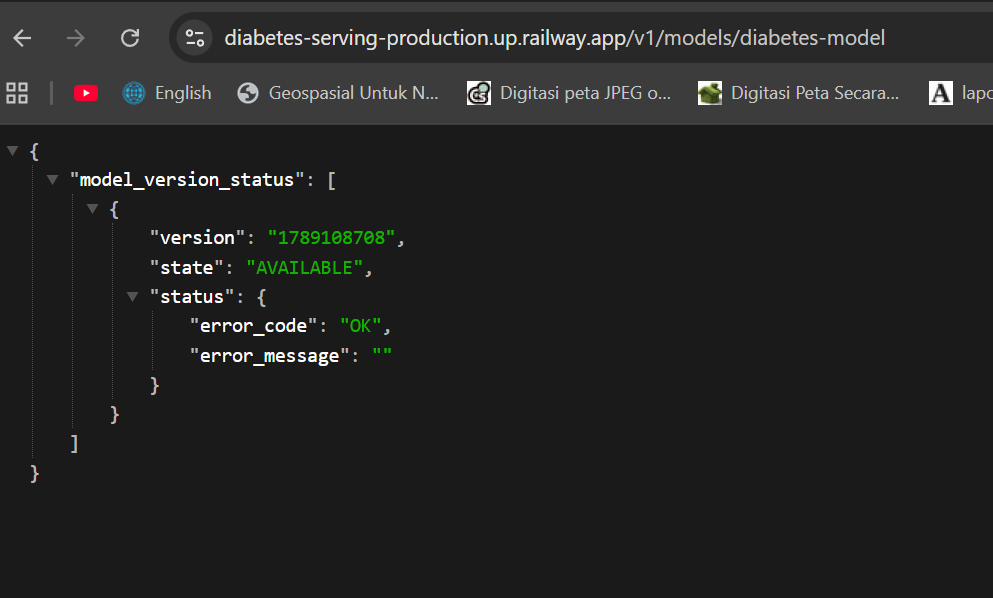

In [18]:
# Display deployment verification screenshot on Railway
display(Image(filename="jaluprayoga-deployment.png", width=900))

## 15. Model Monitoring (Prometheus & Grafana)

A real-time monitoring and observability system is implemented to ensure that TensorFlow Serving operates reliably, efficiently, and with optimal inference performance.

### Observability Architecture:
1. **Metrics Exporter:** Built-in Prometheus metrics exporter enabled in TF Serving on port 8501 (`/monitoring/prometheus/metrics`).
2. **Prometheus Scraping Server:** Periodically pulls real-time operational metrics every 5 seconds (`monitoring/prometheus.yml`).
3. **Grafana Dashboard:** Visualizes server health, inference request rate, throughput, latency percentiles, and HTTP status codes (`monitoring/grafana-dashboard.json`).


In [19]:
# Scrape Prometheus metrics from /monitoring/prometheus/metrics endpoint
response_metrics = requests.get(f"{BASE_URL}/monitoring/prometheus/metrics", timeout=10)
print("=== PROMETHEUS METRICS EXPORTER (GET /monitoring/prometheus/metrics) ===")
print("Status Code:", response_metrics.status_code)
print("Preview Sample Metrics Output:")
for line in response_metrics.text.splitlines()[:25]:
    print(line)

=== PROMETHEUS METRICS EXPORTER (GET /monitoring/prometheus/metrics) ===
Status Code: 200
Preview Sample Metrics Output:
# TYPE :tensorflow:api:op:using_fake_quantization gauge
# TYPE :tensorflow:cc:saved_model:load_attempt_count counter
:tensorflow:cc:saved_model:load_attempt_count{model_path="/models/diabetes-model/1789108708",status="success"} 1
# TYPE :tensorflow:cc:saved_model:load_latency counter
:tensorflow:cc:saved_model:load_latency{model_path="/models/diabetes-model/1789108708"} 98927
# TYPE :tensorflow:cc:saved_model:load_latency_by_stage histogram
:tensorflow:cc:saved_model:load_latency_by_stage_bucket{model_path="/models/diabetes-model/1789108708",stage="init_graph",le="10"} 0
:tensorflow:cc:saved_model:load_latency_by_stage_bucket{model_path="/models/diabetes-model/1789108708",stage="init_graph",le="18"} 0
:tensorflow:cc:saved_model:load_latency_by_stage_bucket{model_path="/models/diabetes-model/1789108708",stage="init_graph",le="32.4"} 0
:tensorflow:cc:saved_model:load_l

1. Active Prometheus Monitoring Targets:


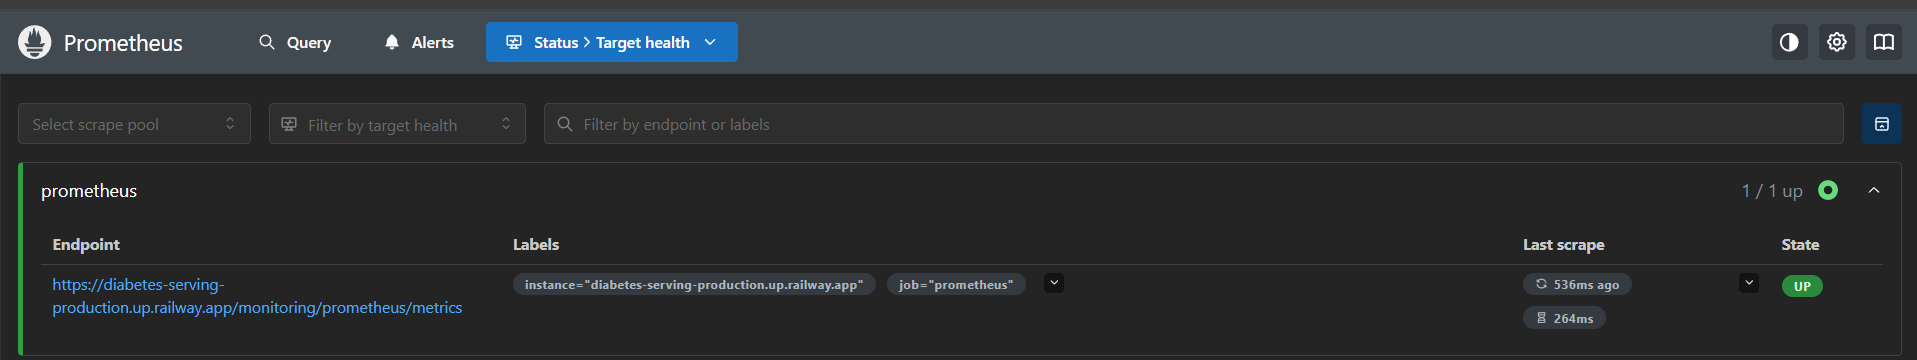


2. Grafana Dashboard Visualization (Latency, Throughput, Status Codes):


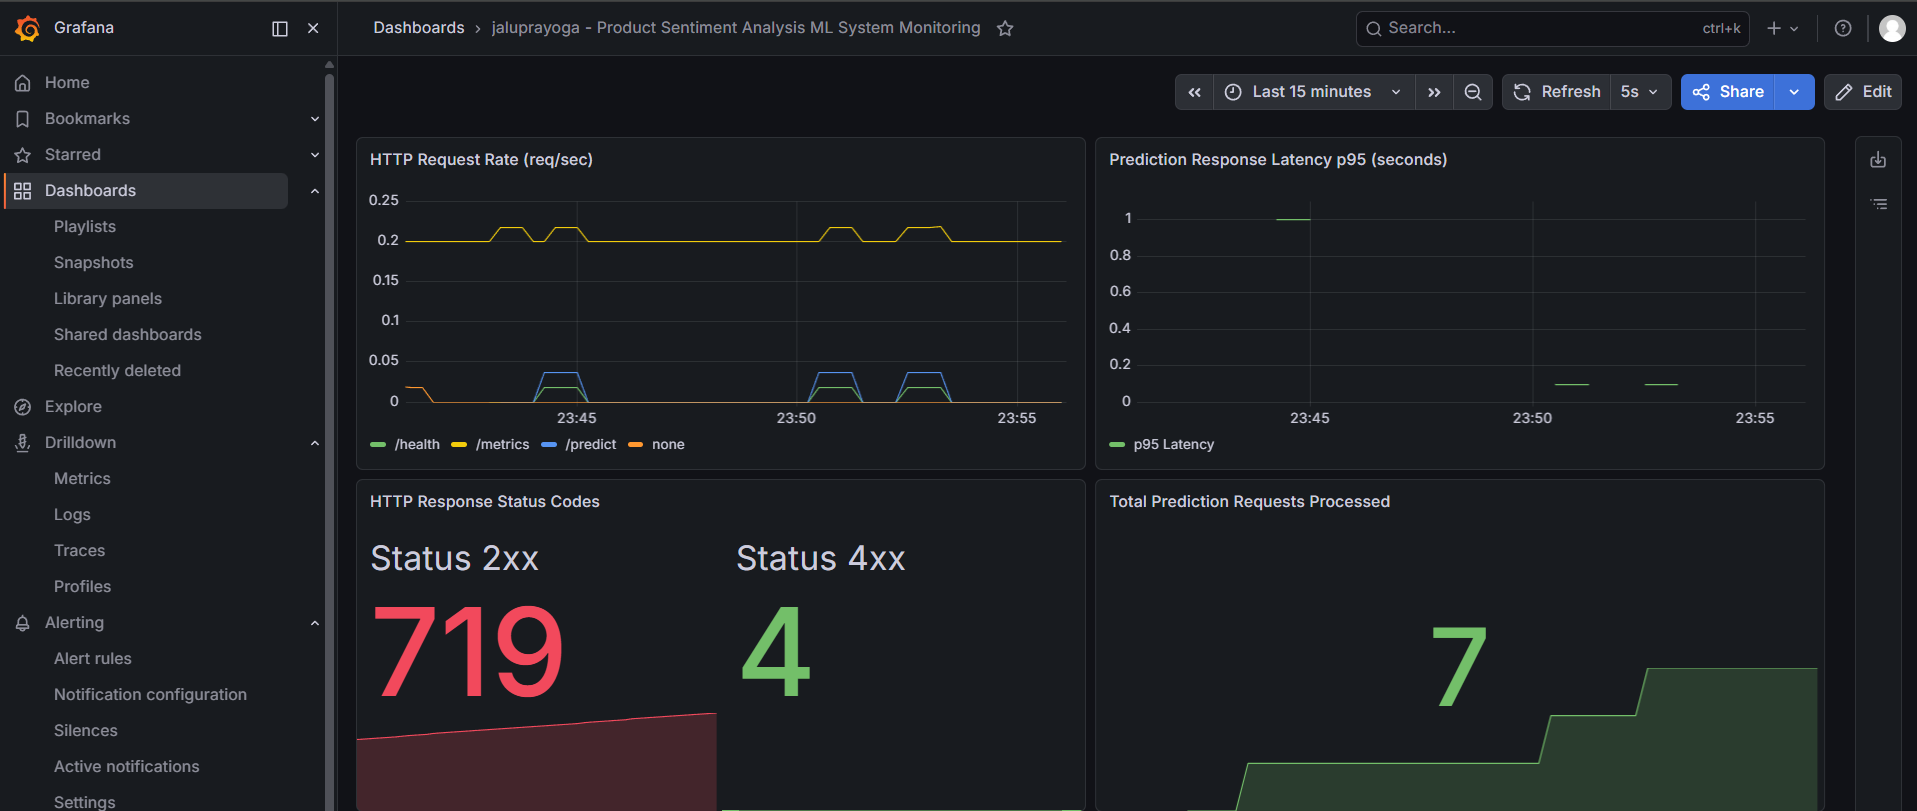

In [20]:
# Display Prometheus target status and Grafana dashboard screenshots
print("1. Active Prometheus Monitoring Targets:")
display(Image(filename="monitoring/jaluprayoga-monitoring.png", width=900))

print("\n2. Grafana Dashboard Visualization (Latency, Throughput, Status Codes):")
display(Image(filename="monitoring/jaluprayoga-grafana-dashboard.png", width=900))